# Comparación de Clasificadores — Especies de Flores

**MAI 540 — Machine Learning | Módulo 3**

Un vivero quiere automatizar la clasificación de especies de flores a partir de las medidas de sus pétalos y sépalos, para no depender de que un botánico revise cada muestra a mano. Tu trabajo es entrenar los tres clasificadores vistos en clase — regresión logística, árbol de decisión y Naive Bayes — sobre el mismo conjunto de datos, compararlos con evidencia, y recomendar cuál usarías.

Dataset: *Iris* (incluido en `scikit-learn`), 150 muestras, 3 especies.

No hay ningún defecto escondido aquí — el notebook funciona de principio a fin. Lo que falta es que **tú entrenes los tres modelos**; el resto (evaluación y gráficas) ya está listo para que compares de forma justa.

## Cómo trabajar con Claude Code en este ejercicio

Esta tarea no es de depuración como la 3.1 — aquí no hay nada que arreglar. El riesgo distinto es que le pidas a Claude Code "entrena los tres modelos y dime cuál es mejor" y te entregue una respuesta sin que tú entiendas por qué.

1. **Entrena tú mismo, con ayuda para dudas puntuales.** Si no recuerdas la sintaxis de `DecisionTreeClassifier` o `GaussianNB`, pregunta eso específicamente — no pidas que te resuelva la celda completa.
2. **Antes de aceptar una conclusión, pide que te explique el porqué.** Si Claude Code te dice "usa regresión logística," pregúntale qué evidencia lo respalda — accuracy promedio, estabilidad entre particiones, o algo más.
3. **Verifica que los tres se evaluaron igual.** Los tres deben pasar por la misma función `evaluar_con_cv` y las mismas variables `X`, `y` — si alguno se evaluó distinto, la comparación no es justa.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

RANDOM_STATE = 42

## 1. Carga de datos

In [2]:
iris = load_iris(as_frame=True)
df = iris.frame.copy()
df['especie'] = df['target'].map(dict(enumerate(iris.target_names)))

X = iris.data.values
y = iris.target.values

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,especie
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


## 2. Exploración inicial

Una matriz de dispersión: cada panel compara dos variables, coloreado por especie.

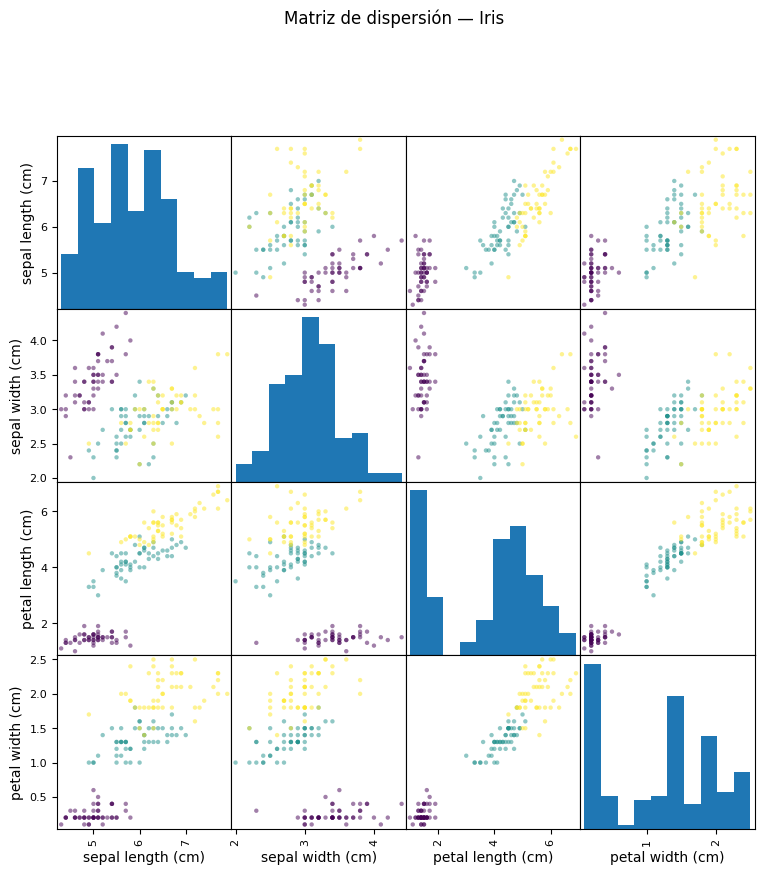

In [3]:
pd.plotting.scatter_matrix(iris.data, c=y, figsize=(9, 9), cmap='viridis', s=40)
plt.suptitle('Matriz de dispersión — Iris', y=1.02)
plt.show()

## 3. Entrena tú los tres clasificadores

Completa las tres funciones. Cada una debe entrenar el modelo indicado sobre `X` y `y`, y devolver el modelo ya entrenado (`.fit()` aplicado).

In [4]:
def entrenar_regresion_logistica(X, y):
    """Entrena una regresión logística sobre el dataset completo."""
    # 1. Crea el modelo: modelo = LogisticRegression(max_iter=5000)
    # 2. Entrénalo sobre todo el dataset: modelo.fit(X, y)
    # 3. Devuélvelo: return modelo
    modelo = LogisticRegression(max_iter=5000)
    modelo.fit(X, y)
    return modelo

In [5]:
def entrenar_arbol_decision(X, y):
    """Entrena un árbol de decisión con profundidad máxima 3 (para que siga siendo interpretable)."""
    # 1. Crea el modelo: modelo = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)
    # 2. Entrénalo sobre todo el dataset: modelo.fit(X, y)
    # 3. Devuélvelo: return modelo
    modelo = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)
    modelo.fit(X, y)
    return modelo

In [6]:
def entrenar_naive_bayes(X, y):
    """Entrena un clasificador Naive Bayes gaussiano."""
    # 1. Crea el modelo: modelo = GaussianNB()
    # 2. Entrénalo sobre todo el dataset: modelo.fit(X, y)
    # 3. Devuélvelo: return modelo
    modelo = GaussianNB()
    modelo.fit(X, y)
    return modelo

## 4. Evaluación con validación cruzada

Un solo split de entrenamiento/prueba deja muy pocos casos para medir el accuracy con confianza (Iris solo tiene 150 muestras). Por eso comparamos con validación cruzada de 10 particiones: cada modelo se entrena y evalúa 10 veces sobre subconjuntos distintos, y miramos tanto el promedio como qué tanto varía entre particiones.

In [7]:
def evaluar_con_cv(modelo, X, y, nombre):
    """Evalúa un modelo con validación cruzada de 10 particiones y reporta media y desviación estándar."""
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(modelo, X, y, cv=cv)
    print(f"{nombre}: media={scores.mean():.4f}  desviación estándar={scores.std():.4f}  "
          f"mínimo={scores.min():.3f}  máximo={scores.max():.3f}")
    return scores

In [8]:
modelo_logreg = entrenar_regresion_logistica(X, y)
modelo_arbol = entrenar_arbol_decision(X, y)
modelo_nb = entrenar_naive_bayes(X, y)

scores_logreg = evaluar_con_cv(LogisticRegression(max_iter=5000), X, y, "Regresión logística")
scores_arbol = evaluar_con_cv(DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE), X, y, "Árbol de decisión")
scores_nb = evaluar_con_cv(GaussianNB(), X, y, "Naive Bayes")

Regresión logística: media=0.9667  desviación estándar=0.0333  mínimo=0.933  máximo=1.000
Árbol de decisión: media=0.9400  desviación estándar=0.0554  mínimo=0.867  máximo=1.000
Naive Bayes: media=0.9533  desviación estándar=0.0521  mínimo=0.867  máximo=1.000


## 5. Visualización de fronteras de decisión

Para ver *cómo* decide cada modelo, no solo *qué tan bien*, entrenamos los tres sobre únicamente dos variables (longitud y ancho del pétalo) y graficamos la región que cada uno asigna a cada especie.

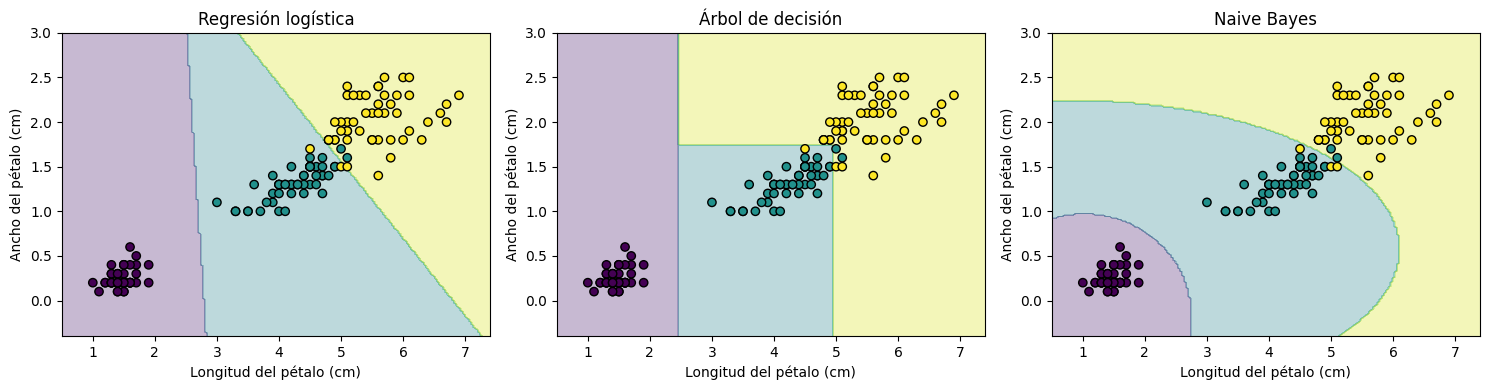

In [13]:
def graficar_frontera(modelo, X_2d, y, titulo, ax, x_label, y_label):
    """Entrena el modelo sobre dos variables y grafica su frontera de decisión."""
    modelo.fit(X_2d, y)
    x_min, x_max = X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5
    y_min, y_max = X_2d[:, 1].min() - 0.5, X_2d[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
    Z = modelo.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
    ax.scatter(X_2d[:, 0], X_2d[:, 1], c=y, edgecolor='k', cmap='viridis')
    ax.set_title(titulo)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)


X_2d = iris.data[['petal length (cm)', 'petal width (cm)']].values

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
graficar_frontera(LogisticRegression(max_iter=5000), X_2d, y, 'Regresión logística', axes[0], 'Longitud del pétalo (cm)', 'Ancho del pétalo (cm)')
graficar_frontera(DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE), X_2d, y, 'Árbol de decisión', axes[1], 'Longitud del pétalo (cm)', 'Ancho del pétalo (cm)')
graficar_frontera(GaussianNB(), X_2d, y, 'Naive Bayes', axes[2], 'Longitud del pétalo (cm)', 'Ancho del pétalo (cm)')
plt.tight_layout()
plt.show()

## 6. Explora la profundidad del árbol

En la sección 3 entrenaste el árbol con `max_depth=3` porque así te lo pedí. Ahora averigua tú si esa profundidad era la correcta.

Entrena el árbol con `max_depth` en 2, 3, 5 y sin límite (`None`). Para cada uno, calcula:
- el accuracy sobre el **mismo conjunto de entrenamiento completo** (`X`, `y`) — esto mide qué tanto "memorizó";
- el accuracy promedio de **validación cruzada** de 10 particiones (usa `evaluar_con_cv`, que ya tienes) — esto mide qué tan bien generaliza.

Grafica ambos accuracy (eje Y) contra la profundidad (eje X), en la misma figura, con una línea para cada uno.

Árbol de decisión (profundidad=2): media=0.9200  desviación estándar=0.0653  mínimo=0.800  máximo=1.000
Árbol de decisión (profundidad=3): media=0.9400  desviación estándar=0.0554  mínimo=0.867  máximo=1.000
Árbol de decisión (profundidad=5): media=0.9333  desviación estándar=0.0516  mínimo=0.867  máximo=1.000
Árbol de decisión (profundidad=None): media=0.9333  desviación estándar=0.0516  mínimo=0.867  máximo=1.000


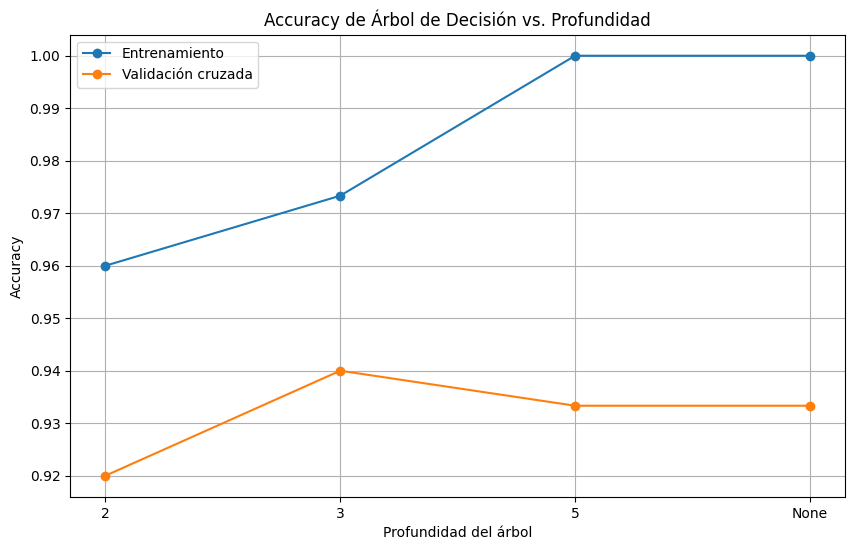

In [10]:
profundidades = [2, 3, 5, None]
accuracy_entrenamiento = []
accuracy_cv = []

for profundidad in profundidades:
    # 1. Crea un árbol con esta profundidad: DecisionTreeClassifier(max_depth=profundidad, random_state=RANDOM_STATE)
    # 2. Entrénalo sobre todo (X, y) con .fit(X, y)
    # 3. Calcula su accuracy sobre el mismo (X, y) con .score(X, y) y agrégalo con
    #    accuracy_entrenamiento.append(...)
    # 4. Crea OTRA instancia nueva del árbol (misma profundidad) y pásala a
    #    evaluar_con_cv(modelo, X, y, nombre) para obtener sus scores de validación cruzada
    # 5. Guarda el promedio de esos scores (scores.mean()) con accuracy_cv.append(...)

    modelo_arbol_profundidades = DecisionTreeClassifier(max_depth=profundidad, random_state=RANDOM_STATE)
    modelo_arbol_profundidades.fit(X, y)
    accuracy_entrenamiento.append(modelo_arbol_profundidades.score(X, y))
    scores_cv_profundidad = evaluar_con_cv(modelo_arbol_profundidades, X, y, f"Árbol de decisión (profundidad={profundidad})")
    accuracy_cv.append(scores_cv_profundidad.mean())

# 6. Convierte las profundidades a texto para el eje X (None no se puede graficar directo):
etiquetados = [str(p) for p in profundidades]
# 7. Grafica dos líneas sobre las mismas etiquetas: una para accuracy_entrenamiento y
#    otra para accuracy_cv, usando plt.plot(etiquetas, ..., marker='o', label='...') dos veces
plt.figure(figsize=(10, 6))
plt.plot(etiquetados, accuracy_entrenamiento, marker='o', label='Entrenamiento')
plt.plot(etiquetados, accuracy_cv, marker='o', label='Validación cruzada')
# 8. Agrega plt.xlabel(...), plt.ylabel(...), plt.legend() y plt.show()
plt.xlabel('Profundidad del árbol')
plt.ylabel('Accuracy')
plt.title('Accuracy de Árbol de Decisión vs. Profundidad')
plt.legend()
plt.grid(True)
plt.show()

¿En qué profundidad empiezan a separarse las dos líneas? Esa separación es la señal de sobreajuste — el árbol sigue mejorando en el conjunto que ya vio, pero deja de mejorar (o empeora) en datos que no vio. Anota en tu informe cuál profundidad elegirías y por qué, con la gráfica como evidencia.

## 7. Justifica las variables de la gráfica de frontera

La sección 5 usó longitud y ancho del pétalo porque yo las elegí. Repite esa misma visualización usando **otro par de variables** (por ejemplo, longitud y ancho del sépalo), y compara.

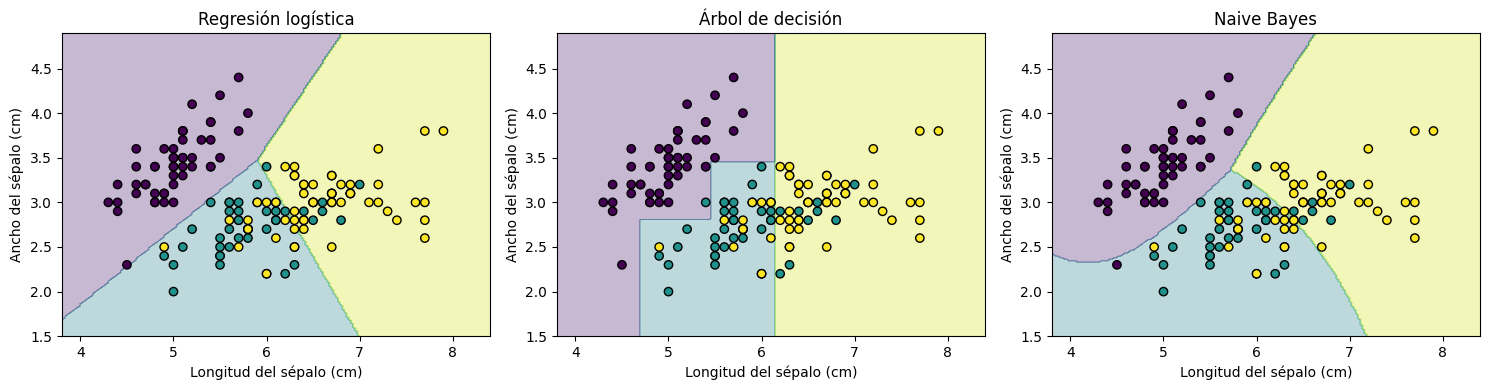

In [14]:
# 1. Elige dos columnas distintas de iris.data, por ejemplo:
#    "sepal length (cm)" y "sepal width (cm)"
# 2. Arma el arreglo: X_2d_alternativo = iris.data[["columna1", "columna2"]].values
# 3. Crea una figura con 3 subplots: fig, axes = plt.subplots(1, 3, figsize=(15, 4))
# 4. Llama graficar_frontera(...) tres veces (una por modelo: regresion logistica, arbol,
#    Naive Bayes), igual que en la seccion 5, pero pasando X_2d_alternativo en vez de X_2d
# 5. Termina con plt.tight_layout() y plt.show()

X_2d_alternativo = iris.data[["sepal length (cm)", "sepal width (cm)"]].values
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
graficar_frontera(LogisticRegression(max_iter=5000), X_2d_alternativo, y, 'Regresión logística', axes[0], 'Longitud del sépalo (cm)', 'Ancho del sépalo (cm)')
graficar_frontera(DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE), X_2d_alternativo, y, 'Árbol de decisión', axes[1], 'Longitud del sépalo (cm)', 'Ancho del sépalo (cm)')
graficar_frontera(GaussianNB(), X_2d_alternativo, y, 'Naive Bayes', axes[2], 'Longitud del sépalo (cm)', 'Ancho del sépalo (cm)')
plt.tight_layout()
plt.show()

¿Qué par de variables separa mejor las tres especies a simple vista? En tu informe, justifica tu respuesta señalando qué observas en las gráficas (qué tanto se traslapan los colores), no solo cuál te parece más bonita.

## 8. Tabla comparativa

In [11]:
tabla = pd.DataFrame({
    'Clasificador': ['Regresión logística', 'Árbol de decisión', 'Naive Bayes'],
    'Accuracy promedio': [scores_logreg.mean(), scores_arbol.mean(), scores_nb.mean()],
    'Desviación estándar': [scores_logreg.std(), scores_arbol.std(), scores_nb.std()],
})
tabla

,Clasificador,Accuracy promedio,Desviación estándar
0,Regresión logística,0.966667,0.033333
1,Árbol de decisión,0.940000,0.055377
2,Naive Bayes,0.953333,0.052068


## 9. Tu recomendación

En tu informe, responde con evidencia de las secciones anteriores:

- ¿Cuál clasificador tiene el mejor accuracy promedio?
- ¿Cuál es el más estable entre particiones (menor desviación estándar)?
- Mirando las gráficas de frontera de decisión: ¿la forma de la frontera de cuál modelo te parece más razonable para este problema?
- ¿Qué profundidad del árbol elegirías, según la gráfica de la sección 6? ¿En qué punto empieza a sobreajustar?
- ¿Qué par de variables usaste en la sección 7, y por qué separa mejor (o peor) que longitud/ancho del pétalo?
- Considerando todo lo anterior — no solo el accuracy — ¿cuál recomendarías para el vivero, y por qué?